In [ ]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

from specula.mmlib.utils import shift_image, get_frame_pupil_centers

[[-34.82729433 -29.13370402]
 [-33.43978634  28.66589045]
 [ 34.51930124 -31.13193683]
 [ 33.74777943  31.59975039]]


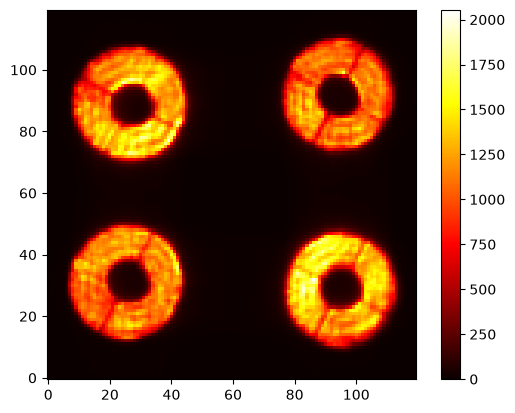

In [3]:
img = np.load('/raid1/mmenessini/calibration/EKARUS/data/OnSky_frame.npy')

ref_centers = get_frame_pupil_centers(img)
avg_center = np.mean(ref_centers,axis=0)
ref_dcenters = ref_centers-avg_center
print(ref_dcenters)

xmin = int(np.round(avg_center[0]))-60
xmax = int(np.round(avg_center[0]))+60
ymin = int(np.round(avg_center[1]))-60
ymax = int(np.round(avg_center[1]))+60

img = img[ymin:ymax,xmin:xmax]

plt.figure()
plt.imshow(img,origin='lower',cmap='hot')
plt.colorbar()

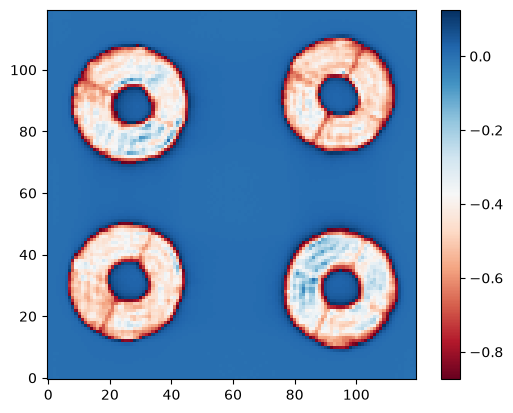

In [4]:
def two_level_thresholding(image, thr1 = 0.1, thr2 = 0.25):    
    min_val, max_val = float(np.min(image)), float(np.max(image))
    s1 = min_val + (max_val - min_val) * thr1

    thresh_img = image.copy()
    thresh_img[thresh_img < s1] = 0

    s2 = float(np.mean(thresh_img[thresh_img > 0])) * thr2
    mask = thresh_img >= s2
    return mask

est_mask = two_level_thresholding(img)
plt.figure()
plt.imshow(img/np.max(img)-est_mask,origin='lower',cmap='RdBu')
plt.colorbar()

[[-0.01453846 -0.70136278]
 [ 0.12737027  2.04762959]
 [-0.15130338 -0.6023779 ]
 [ 0.03847157 -0.74388891]]


Text(0.5, 1.0, 'Increase y (second row) of pupil 1')

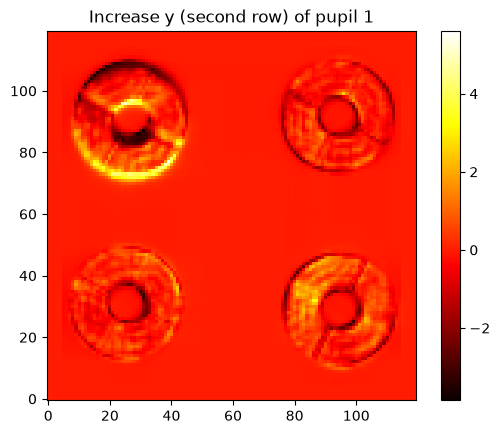

In [5]:
frame = fits.getdata('/raid1/mmenessini/results/EKARUS/frame.fits')[0,60:180,60:180]

centers = get_frame_pupil_centers(frame,xhalf=60,yhalf=60)
dcenters = centers-np.mean(centers,axis=0)
tilt_coeffs = ref_dcenters.T/30
print(dcenters-ref_dcenters)

plt.figure()
plt.imshow(frame,origin='lower',cmap='hot',vmax=200)
plt.imshow(img/np.mean(img)-frame/np.mean(frame),origin='lower',cmap='hot')
plt.colorbar()
plt.title('Increase y (second row) of pupil 1')

In [6]:
from specula.mmlib.utils import get_pupil_mask

sky_pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')[60:180,60:180]


2026-08-16 18:38:35,012 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-16 18:38:35,137 [INFO]: [specula]: Default device is GPU number 0


[123.23573425 105.19869917]


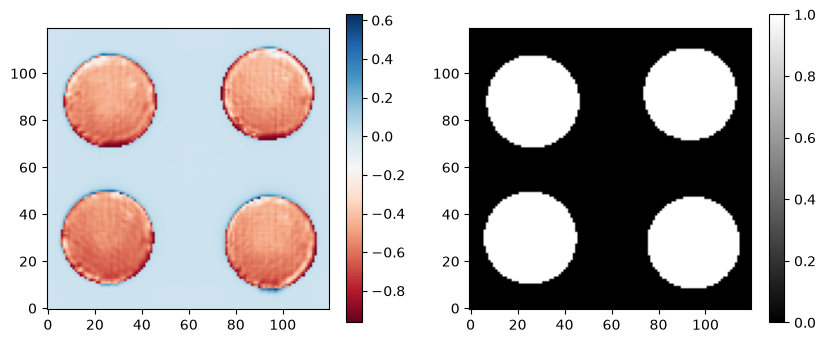

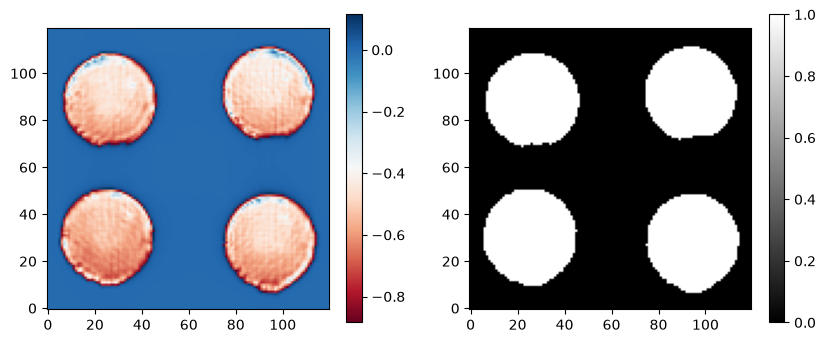

In [27]:
def shift_image(image, shift, axis):
    shift_int = int(np.floor(shift))
    shift_frac = shift - shift_int
    def integer_shift(img, pixels, ax):
        if pixels == 0:
            return img.copy()
        pad_width = [(0, 0), (0, 0)]
        if pixels > 0:
            pad_width[ax] = (pixels, 0)  # Pad start (left/top)
            sliced_img = np.pad(img, pad_width, mode='constant', constant_values=0)
            if ax == 0: return sliced_img[:-pixels, :]
            else:       return sliced_img[:, :-pixels]
        else:
            pad_width[ax] = (0, abs(pixels))  # Pad end (right/bottom)
            sliced_img = np.pad(img, pad_width, mode='constant', constant_values=0)
            if ax == 0: return sliced_img[abs(pixels):, :]
            else:       return sliced_img[:, abs(pixels):]
    img_floor = integer_shift(image, shift_int, axis)
    img_ceil = integer_shift(image, shift_int + 1, axis)
    shifted_image = img_floor * (1.0 - shift_frac) + img_ceil * shift_frac
    return shifted_image


im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260802_233704.fits')
imold = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260731_233429.fits')
imold = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260815_194918.fits')
# im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260729_122235.fits')
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')[60:180,60:180]

# imframe = im[:,290].reshape([240,240])
# imframe = np.std(im,axis=1).reshape([240,240])
imframe = imold[:,399].reshape([240,240])
imframe = np.std(imold,axis=1).reshape([240,240])

ref_centers = get_frame_pupil_centers(imframe)
savg_center = np.mean(ref_centers,axis=0)

hsize = 120
frimg = shift_image(imframe, shift=120-savg_center[1], axis=0)
frimg = shift_image(frimg, shift=120-savg_center[0], axis=1)
frimg = frimg[60:180,60:180]

print(savg_center)

# np.save('/raid1/mmenessini/calibration/EKARUS/data/OnBench_frame.npy',imframe)

thr_mask = two_level_thresholding(frimg)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(frimg/np.max(frimg)-pyr_mask,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(pyr_mask,origin='lower',cmap='gray')
plt.colorbar()
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(frimg/np.max(frimg)-thr_mask,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(thr_mask,origin='lower',cmap='gray')
plt.colorbar()

In [8]:
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/reordered_unobs_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/reordered_unobs_DM468_160pixels.fits')).astype(bool)

# # from scipy.ndimage import rotate
# # idx_mask = np.where(pupil_mask)

# # rot_deg = 180
# # flip_iff = np.zeros_like(iffs)
# # for i in range(iffs.shape[1]):
# #     mode_img = np.zeros(pupil_mask.shape)
# #     mode_img[idx_mask] = iffs[:,i]
# #     mode_img = np.reshape(mode_img,pupil_mask.shape)
# #     flip_img = mode_img[:,::-1]
# #     # flip_iff[:,i] = flip_img[idx_mask]
# #     rot_img = rotate(flip_img,angle=rot_deg,reshape=False)
# #     flip_iff[:,i] = rot_img[idx_mask]

# from specula.data_objects.ifunc import IFunc    
# ifunc_obj = IFunc(
#         ifunc=flip_iff.T,
#         mask=(pupil_mask).astype(np.uint8) # bin_pup_mask
#     )
# ifunc_obj.save('/raid1/mmenessini/calibration/EKARUS/ifunc/reordered_unobs_DM468_ifunc.fits', overwrite=True)

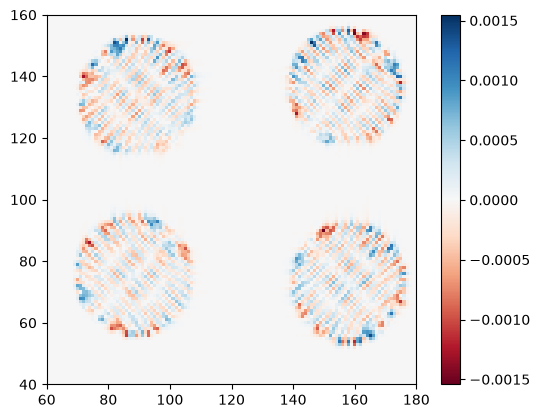

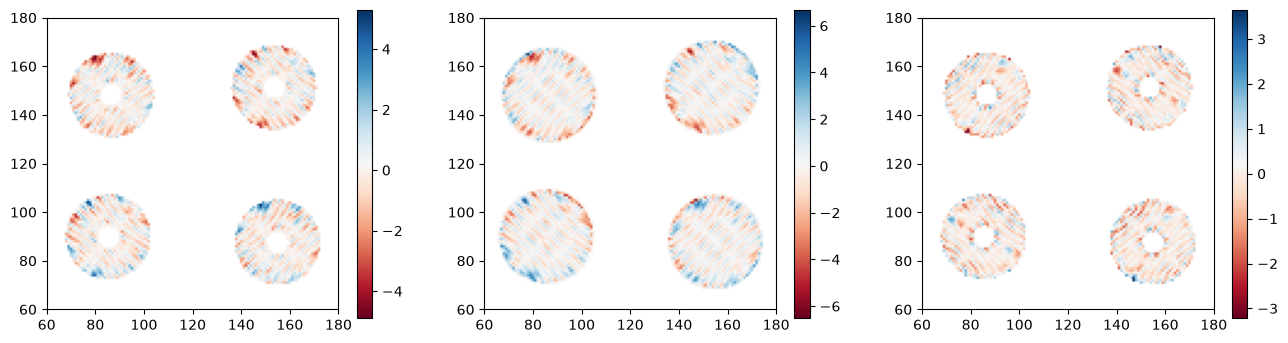

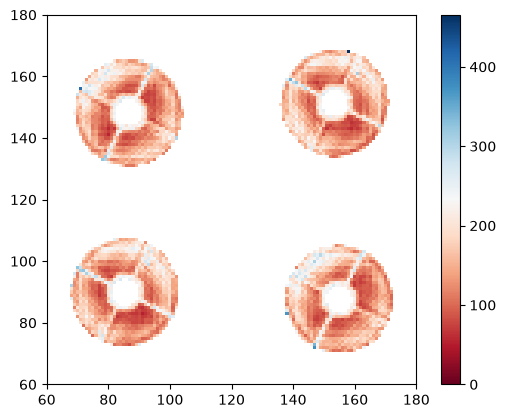

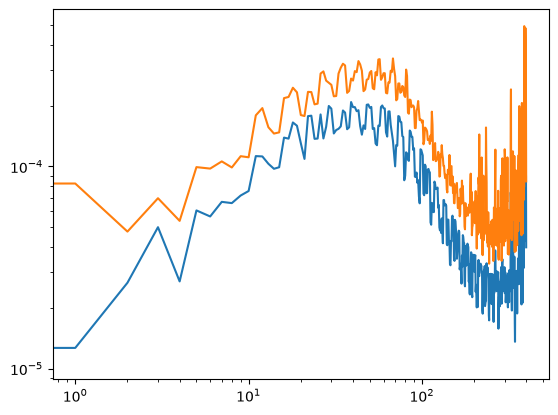

In [23]:
rMod = 5
skyim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onsky_dm468_im.fits')
skyim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onsky_measIF_dm468_im.fits')
benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onbench_dm468_im.fits')
benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onbench_measIF_dm468_im.fits')
# benchim = fits.getdata('/raid1/mmenessini/calibration/EKARUS/im/pyr3.0_onbench_measIF_bestshift_dm468_im.fits')
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')
pup_ids_sky = pup_hdu[1].data
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_ids_bench = pup_hdu[1].data

sky_pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')

j = 399
npix = 240
diff = np.zeros([npix,npix])
fimg_sky = np.zeros([npix,npix])
fimg_bench = np.zeros([npix,npix])
im_onbench_crop = np.zeros_like(skyim)
for i in range(400):
    rtot = 0
    for k in range(4):
        valid_ids = pup_ids_bench[:,k] != -1
        len_ids = np.sum(valid_ids)
        np.put(fimg_bench, pup_ids_bench[valid_ids,k], benchim[rtot:rtot+len_ids,i])
        rtot += len_ids
    rtot = 0
    for k in range(4):
        valid_ids = pup_ids_sky[:,k] != -1
        len_ids = np.sum(valid_ids)
        np.put(fimg_sky, pup_ids_sky[valid_ids,k], skyim[rtot:rtot+len_ids,i])
        im_onbench_crop[skyim.shape[0]//4:skyim.shape[0]//4+len_ids,i] = fimg_bench.flatten()[pup_ids_sky[valid_ids,k]]
        rtot += len_ids
    sky2d = fimg_sky.reshape([npix,npix])
    bench2d = fimg_bench.reshape([npix,npix])
    if i == j:
        f2d_sky = sky2d/np.std(sky2d[sky_pyr_mask])
        f2d_bench = bench2d/np.std(bench2d[sky_pyr_mask])
    diff += abs(sky2d/np.std(sky2d[sky_pyr_mask])-bench2d/np.std(bench2d[sky_pyr_mask]))

# from specula.data_objects.intmat import Intmat
# im_obj = Intmat(intmat=im_onbench_crop)
# im_obj.save('/raid1/mmenessini/calibration/EKARUS/im/pyr5.0_onbench_crop_measIF_im.fits',overwrite=True)

plt.figure()
plt.imshow(imold[:,j].reshape([240,240]),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([40,160])

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(f2d_sky,mask=1-sky_pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(f2d_bench,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(f2d_bench-f2d_sky,mask=1-sky_pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])

plt.figure()
plt.imshow(np.ma.masked_array(diff,mask=1-sky_pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])

plt.figure()
plt.loglog(np.diag(skyim.T @ skyim))
# plt.loglog(np.diag(im_onbench_crop.T @ im_onbench_crop))
plt.loglog(np.diag(benchim.T @ benchim))
# plt.loglog(np.diag(imold.T @ imold))
# plt.loglog(np.diag(im.T @ im))

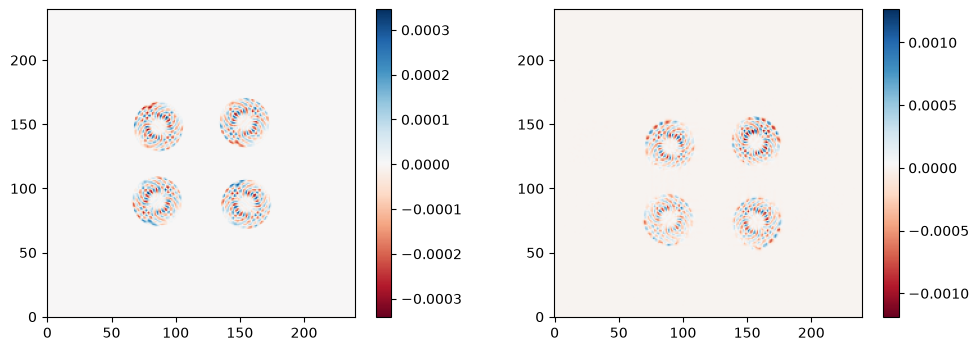

In [10]:
synim = fits.getdata('/raid1/mmenessini/calibration/EKARUS/im/pyr5.0_dm468_onbench_synim.fits')
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_ids = pup_hdu[1].data

j = 230
npix = 240
fimg = np.zeros([npix,npix])
rtot = 0
for i in range(4):
    valid_ids = pup_ids[:,i] != -1
    len_ids = np.sum(valid_ids)
    np.put(fimg, pup_ids[valid_ids,i], synim[rtot:rtot+len_ids,j])
    rtot += len_ids
# fimg[pyr_mask] = synim[:,j]
f2d = fimg.reshape([npix,npix])

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(f2d,origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(imold[:,j].reshape([240,240]),origin='lower',cmap='RdBu')
plt.colorbar()

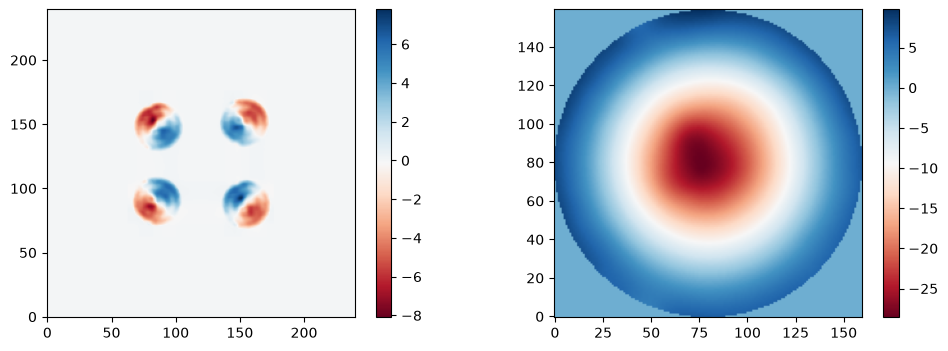

In [11]:
frames = fits.getdata('/raid1/mmenessini/results/EKARUS/calib_frame.fits')
phases = fits.getdata('/raid1/mmenessini/results/EKARUS/dm_ef.fits')[:,1,:,:]

# mask = np.sum(abs(phases),axis=0)==0
# print(mask.shape,phases.shape)
# rmsvec = np.zeros(300)
# for j in range(300):
#     phi = phases[j]
#     rmsvec[j] = np.std(phi[~mask])

# plt.figure()
# plt.plot(rmsvec)

idx = 3
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(frames[1+idx*2]-frames[0+idx*2],origin='lower',cmap='RdBu')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(phases[1+idx*2]-phases[0+idx*2],origin='lower',cmap='RdBu')
plt.colorbar()

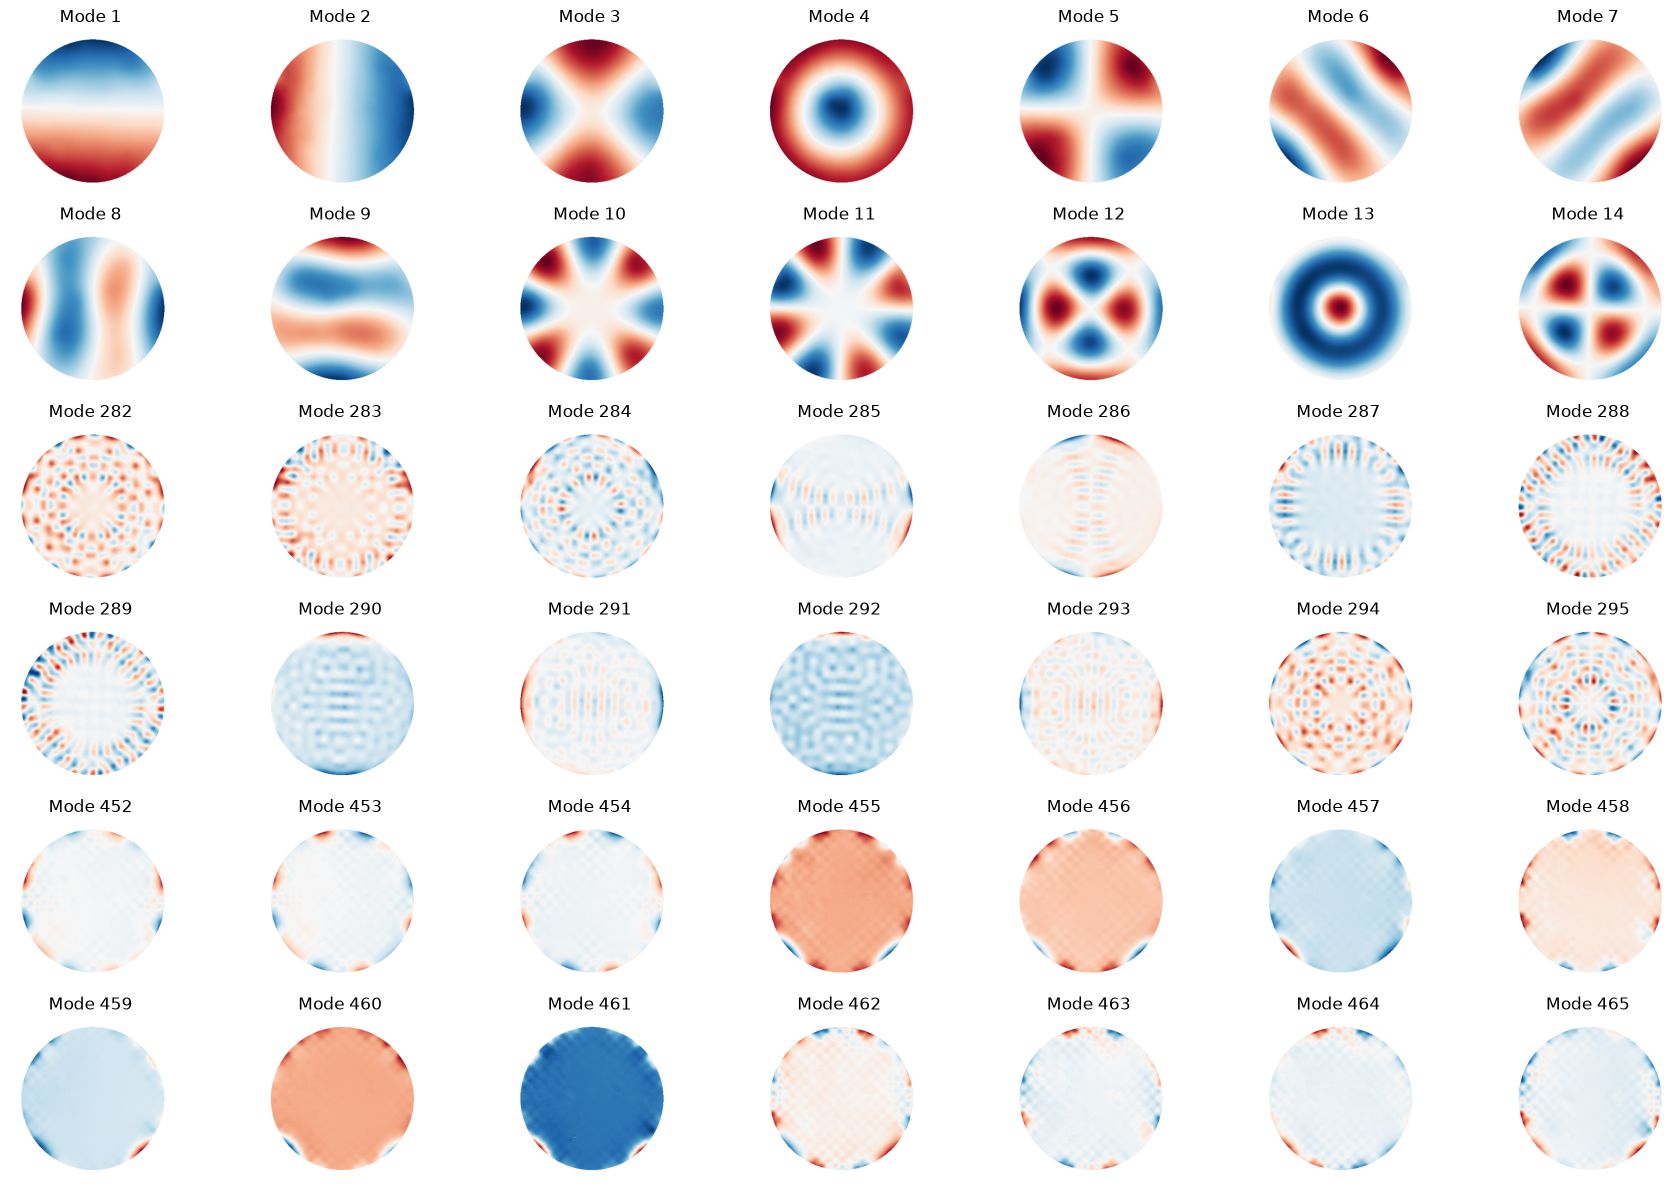

In [12]:
# m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_central_obstruction.npy')
iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/reordered_IFs.fits')
pupil_mask = (1-fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IFmask.fits')).astype(bool)
m2c = np.load('/raid1/mmenessini/calibration/EKARUS/m2c/M2C_KL_OOPAO_synthetic.npy')
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/simul_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/simul_DM468_160pixels.fits')).astype(bool)
# m2c = fits.getdata('/raid1/mmenessini/calibration/EKARUS/m2c/simul_unobs_DM468_m2c.fits')
# iffs = fits.getdata('/raid1/mmenessini/calibration/EKARUS/ifunc/simul_unobs_DM468_ifunc.fits')
# pupil_mask = (fits.getdata('/raid1/mmenessini/calibration/EKARUS/pupilstop/simul_unobs_DM468_160pixels.fits')).astype(bool)

kl_basis = (iffs @ m2c).T #iffs.T #
max_modes = 42
mode_display = np.zeros((max_modes, pupil_mask.shape[0], pupil_mask.shape[1]))
idx_mask = np.where(pupil_mask)
mode_ids = np.zeros(max_modes,dtype=int)

for i in range(max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = i+1
    mode_img[idx_mask] = kl_basis[i]
    mode_display[i] = mode_img
for i in range(max_modes//3,2*max_modes//3):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]//1.5-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img
for i in range(2*max_modes//3,max_modes):
    mode_img = np.zeros(pupil_mask.shape)
    mode_ids[i] = kl_basis.shape[0]-max_modes+i
    mode_img[idx_mask] = kl_basis[mode_ids[i]]
    mode_display[i] = mode_img

# Plot the reshaped modes
n_rows = 6 #int(np.round(np.sqrt(max_modes)))
n_cols = 7 #int(np.ceil(max_modes / n_rows))
plt.figure(figsize=(18, 12))
for i in range(max_modes):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.ma.masked_array(mode_display[i],mask=1-pupil_mask),origin='lower',cmap='RdBu')
    plt.title(f'Mode {mode_ids[i]}')
    plt.axis('off')
plt.tight_layout()